# 12/18
first try to compare to around WVR data to Balloon data 

In [ ]:
"""
read from floder ./Data/*.csv to have all am data (time and pwv)
read balloon data from ./Data/Alldate_balloon_SP.csv
regenerate a new csv by following conditions:
for each balloon data time, find am data within +/- 120 min
save new csv to ./around_balloon_am_data.csv
"""

import pandas as pd 
import numpy as np  
#import matplotlib.pyplot as plt
import glob
import os
from datetime import datetime, timedelta
import pickle
import matplotlib.pyplot as plt   

try:
    for file in glob.glob('./around/*.csv'):
        os.remove(file)
except OSError as e:
    print(f"Error removing files: {e}")

am_fn_list = glob.glob('./Data/time*.csv')
balloon_fn = './Data/Alldate_balloon_SP.csv'

am_fn_list.sort()
all_am_df = pd.DataFrame()

for am_fn in am_fn_list:
    am_df = pd.read_csv(am_fn, dtype={'DATE(YYYYMMDD)': str, 'START TIME(HHMMSS.Microsec)': str, 'PWV TOTAL zenith': str})
    am_df['TIME'] = pd.to_datetime(am_df['DATE(YYYYMMDD)'] + ' ' + am_df['START TIME(HHMMSS.Microsec)'], format='%Y%m%d %H%M%S.%f')
    am_df = am_df.sort_values(by='TIME') 
    am_TIME = am_df['TIME'].dt.strftime('%Y-%m-%d %H:%M:%S')
    am_PWV = am_df['PWV TOTAL zenith'].str.split(' ').str[0].astype(float)
    am_df_s = pd.DataFrame({'Time': am_TIME, 'PWV': am_PWV})
    all_am_df = pd.concat([all_am_df, am_df_s], ignore_index=True)

#print(f'Total AM data points: {len(all_am_df)} \n {all_am_df.head(3)} \n')
balloon_df = pd.read_csv(balloon_fn)
balloon_df['Date(YYYYMMDD_HHMMSS)'] = pd.to_datetime(balloon_df['Date(YYYYMMDD_HHMMSS)'], format='%Y%m%d_%H%M%S')
#print(f'Total Balloon data points: {len(balloon_df)} \n {balloon_df.head(3)} \n')

#save csv function for each balloon time
def saveAround(balloon_date_fn, am_time, am_pwv, balloon_time, balloon_pwv):
    if os.path.exists(f'around/around_{balloon_date_fn}.csv') is False:
        with open(f'around/around_{balloon_date_fn}.csv', 'w+') as f:
            f.write('am_TIME, am_PWV(um), balloon_TIME, balloon_PWV(um) \n')
            f.write(f'{am_time}, {am_pwv}, {balloon_time}, {balloon_pwv} \n')
    else:
        with open(f'around/around_{balloon_date_fn}.csv', 'a+') as f:
            f.write(f'{am_time}, {am_pwv}, {balloon_time}, {balloon_pwv} \n')

am_num_out = 0

for i in range(3, len(balloon_df)):
    num_balloon = i
    balloon_time = balloon_df.loc[num_balloon, 'Date(YYYYMMDD_HHMMSS)']
    balloon_time_dt = datetime.strptime(str(balloon_time), '%Y-%m-%d %H:%M:%S')
    balloon_date_fn = str(balloon_time_dt.strftime('%y%m%d_%H'))
    #print(f'Processing balloon time: {balloon_date_fn}')
    balloon_pwv = balloon_df.loc[num_balloon, 'PWV(um)']

    for j in range(am_num_out, len(all_am_df)):
        num_am = j
        am_time = all_am_df.loc[num_am, 'Time']
        am_time_dt = datetime.strptime(am_time, '%Y-%m-%d %H:%M:%S')
        am_pwv = all_am_df.loc[num_am, 'PWV']
        #print(f'  Checking AM data index: {num_am} to {am_time_dt}' )
        if balloon_time_dt.hour == 0:
            if am_time_dt.month == balloon_time_dt.month and am_time_dt.year == balloon_time_dt.year: 
                if abs((am_time_dt - balloon_time_dt).total_seconds()) <= 7200:
                    saveAround(balloon_date_fn, am_time, am_pwv, balloon_time, balloon_pwv)
                    am_num_out += 1
                    continue
                elif am_time_dt.day < balloon_time_dt.day:
                    am_num_out += 1
                    continue
                elif am_time_dt.day > balloon_time_dt.day:
                    am_num_out += 1
                    break

        if balloon_time_dt.hour == 12:
            same_day = am_time_dt.day == balloon_time_dt.day
            same_month = am_time_dt.month == balloon_time_dt.month
            same_year = am_time_dt.year == balloon_time_dt.year
            if same_day and same_month and same_year:
                if balloon_time_dt.hour - am_time_dt.hour > 2:
                    am_num_out += 1
                    continue
                elif abs((am_time_dt - balloon_time_dt).total_seconds()) <= 7200:
                    saveAround(balloon_date_fn, am_time, am_pwv, balloon_time, balloon_pwv)
                    am_num_out += 1
                    continue
                elif am_time_dt.hour - balloon_time_dt.hour > 2:
                    am_num_out += 1
                    break
                else:
                    print(f"not excepted case for {am_time_dt}")
                    am_num_out += 1
                    continue

    if i == 1:
        break #test
    if i % 20 == 0:
        print(f'Done for balloon time: {balloon_date_fn} \n')



In [ ]:
# import pandas as pd 
# import numpy as np  
# import matplotlib.pyplot as plt
# import glob
# import os
# from datetime import datetime, timedelta
# import pickle
# import matplotlib.pyplot as plt 

# """
# Plot the Histogram for PWV diff(%) for each csv files
# """

# around_fn_list = glob.glob('./around/*.csv')
# fig2 = plt.figure(figsize=(8,6))

# for around_fn in around_fn_list:
#     around_df = pd.read_csv(around_fn)
#     # Strip whitespace from column names
#     around_df.columns = around_df.columns.str.strip() ###

#     am_PWV = around_df['am_PWV(um)'].values
#     balloon_PWV = around_df['balloon_PWV(um)'].values
#     pwv_diff_perc = (am_PWV - balloon_PWV) / balloon_PWV * 100

#     fig1 = plt.figure(figsize=(8,6))
#     plt.hist(pwv_diff_perc, bins=30, alpha=0.7, color='blue', edgecolor='black')
#     plt.title(f'Histogram of PWV Difference (%) for {os.path.basename(around_fn)}')
#     plt.xlabel('PWV Difference (%)')
#     plt.ylabel('Frequency')
#     plt.grid(axis='y', alpha=0.75)
#     #plt.axvline(pwv_diff_perc.mean(), color='red', linestyle='dashed', linewidth=1)
#     #plt.text(pwv_diff_perc.mean(), plt.ylim()[1]*0.9, f'Mean: {pwv_diff_perc.mean():.2f}%', color='red')
#     fig1.savefig(f'Hist/{os.path.basename(around_fn).replace(".csv", "_pwv_diff_hist.png")}')
#     #plt.show()
#     plt.close(fig1)

#     plt.figure(fig2)
#     plt.hist(pwv_diff_perc, bins=30, alpha=0.7, color='green', edgecolor='black', label='AM PWV')
#     plt.title(f'Histogram of PWV Difference (%) for All')
#     plt.xlabel('PWV Difference (%)')
#     plt.ylabel('Frequency')
#     plt.grid(axis='y', alpha=0.75)
# plt.show(fig2)

In [ ]:
# import pandas as pd 
# import numpy as np  
# import matplotlib.pyplot as plt
# import glob
# import os
# from datetime import datetime, timedelta
# import pickle
# import matplotlib.pyplot as plt 

# # one plot show deltaT(x-axis) vs delraPWV(y-axis)

# around_fn_list = glob.glob('./around/*.csv')
# #fig2 = plt.figure(figsize=(8,6))
# total_data = {
#     'delta_T': [],
#     'pwv_diff_perc': []
# }

# i = 0

# for around_fn in around_fn_list:
#     around_df = pd.read_csv(around_fn)
#     # Strip whitespace from column names
#     around_df.columns = around_df.columns.str.strip() ###

#     am_PWV = around_df['am_PWV(um)'].values
#     balloon_PWV = around_df['balloon_PWV(um)'].values
#     pwv_diff_perc = (am_PWV ) / balloon_PWV 
#     around_df['pwv_diff_perc'] = pwv_diff_perc

#     am_TIME = around_df['am_TIME'].values
#     balloon_TIME = around_df['balloon_TIME'].values
#     delta_T = []
#     for am_t, bal_t in zip(am_TIME, balloon_TIME):
#         am_time_dt = datetime.strptime(am_t, '%Y-%m-%d %H:%M:%S')
#         bal_time_dt = datetime.strptime(bal_t, ' %Y-%m-%d %H:%M:%S')
#         delta_t = (am_time_dt - bal_time_dt).total_seconds() / 60  # in minutes
#         delta_T.append(delta_t)

#     around_df['delta_T'] = delta_T
#     around_df = around_df.sort_values(by='delta_T')
#     #print(around_df.head(10))
#     total_data['pwv_diff_perc'].extend(pwv_diff_perc)
#     total_data['delta_T'].extend(delta_T)

#     # if i < 20:
#     #     i += 1
#     #     plt.figure(figsize=(10,6))
#     #     plt.scatter(around_df['delta_T'], around_df['pwv_diff_perc'])
#     #     plt.show()
#     #     plt.close()


# #print(total_data['delta_T'])

# plt.figure(figsize=(10,6))
# plt.scatter(total_data['delta_T'], total_data['pwv_diff_perc'])
# #plt.plot(total_data['delta_T'], total_data['pwv_diff_perc'])
# plt.xlabel('Time Difference (minutes)')
# plt.ylabel('PWV Difference (am/B)')
# plt.title('PWV Difference (am/B) vs Time Difference (minutes) for All Data')
# plt.xlim(50, 130)
# plt.savefig('PWV(am%B)vsTime_All_Data.png')
# plt.show()
# plt.close()


# plt.figure(figsize=(10,6))
# plt.hist(total_data['pwv_diff_perc'], bins=50, alpha=0.7, color='blue', edgecolor='black')
# plt.title('Histogram of PWV Difference (am/B) for All Data')
# plt.xlabel('PWV Difference (am/B)')
# plt.ylabel('Frequency')
# plt.grid(axis='y', alpha=0.75)
# #plt.xlim(0, 50)
# plt.savefig('Hist_All_Data_PWV(am%B)_Diff.png')
# plt.show()
# plt.close()

# plt.figure
# plt.hist(total_data['delta_T'], bins=50, alpha=0.7, color='orange', edgecolor='black')
# plt.title('Histogram of Time Difference for All Data')
# plt.xlabel('Time Difference (minutes)')
# plt.ylabel('Frequency')
# plt.savefig('Hist_All_Data_Time_Diff.png')
# plt.show()
# plt.close()

In [92]:
import pandas as pd 
import numpy as np  
import matplotlib.pyplot as plt
import glob
import os
from datetime import datetime, timedelta
import pickle
import matplotlib.pyplot as plt 

"""
Plot the Histogram for PWV diff(%) for each csv files
"""

try:
    os.remove('Total_around_stats.txt')
except OSError as e:
    print(f"Error creating directory: {e}")

around_fn_list = glob.glob('./around/*.csv')

total_data_pwv_diff = []
total_data_DeltaT = []

for around_fn in around_fn_list:
    around_df = pd.read_csv(around_fn)
    # Strip whitespace from column names
    around_df.columns = around_df.columns.str.strip() ###

    am_PWV = around_df['am_PWV(um)'].values
    balloon_PWV = around_df['balloon_PWV(um)'].values
    pwv_diff_perc = (am_PWV - balloon_PWV) / balloon_PWV * 100
    total_data_pwv_diff.extend(pwv_diff_perc)

    am_TIME = around_df['am_TIME'].values
    balloon_TIME = around_df['balloon_TIME'].values
    
    for am_t, bal_t in zip(am_TIME, balloon_TIME):
        am_time_dt = datetime.strptime(am_t, '%Y-%m-%d %H:%M:%S')
        bal_time_dt = datetime.strptime(bal_t, ' %Y-%m-%d %H:%M:%S')
        delta_t = int((am_time_dt - bal_time_dt).total_seconds() / 60)  # in minutes
        if delta_t not in total_data_DeltaT:
            if (delta_t + 1) in total_data_DeltaT:
                delta_t += 1
            elif (delta_t - 1) in total_data_DeltaT:
                delta_t -= 1
        total_data_DeltaT.append(delta_t)

total_data = pd.DataFrame({
    'PWV_diff': total_data_pwv_diff,
    'Delta_T': total_data_DeltaT
})

total_data.sort_values(by='Delta_T', inplace=True)

#find all possible delta_T in total_data
unique_delta_T = total_data['Delta_T'].unique()
print(f'Unique Delta_T values: {unique_delta_T}')
for unique_t in unique_delta_T:
    subset = total_data[total_data['Delta_T'] == unique_t]
    mean_pwv_diff = subset['PWV_diff'].mean()
    std_pwv_diff = subset['PWV_diff'].std()
    count = len(subset)

    with open('Total_around_stats.txt', 'a+') as f:
        f.write(f"Delta_T: {unique_t} min, Count: {count}, Mean PWV Diff (%): {mean_pwv_diff:.2f}, Std Dev: {std_pwv_diff:.2f}\n")
    
    #make plot for each subset

    plt.figure(figsize=(8,6))
    plt.hist(subset['PWV_diff'], bins=30, alpha=0.7, color='blue', edgecolor='black',
             label=f'Mean: {mean_pwv_diff:.2f}%, Std Dev: {std_pwv_diff:.2f}, Count: {count}')
    plt.title(f'Histogram of PWV Difference (%) for Delta_T = {unique_t} min')
    plt.xlabel('PWV Difference (%)')
    plt.ylabel('Frequency')
    plt.grid(axis='y', alpha=0.75)
    plt.legend()
    if count > 200:
        plt.savefig(f'Hist/DeltaT_{unique_t}_pwv_diff.png')
    else:
        plt.savefig(f'Hist/LessDPS/DeltaT_{unique_t}_pwv_diff.png')
    plt.close()
    

Unique Delta_T values: [-118 -113 -108 -103  -98  -93  -88  -83  -78  -73  -68  -58  -53  -48
  -43  -38  -33  -28  -23  -18  -13   -8   61   66   71   76   81   86
   91   96  101  106  112]


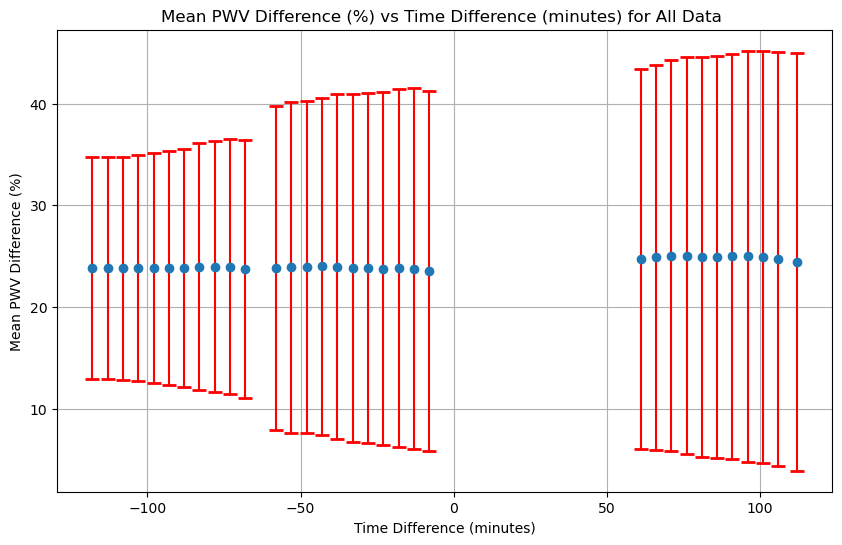

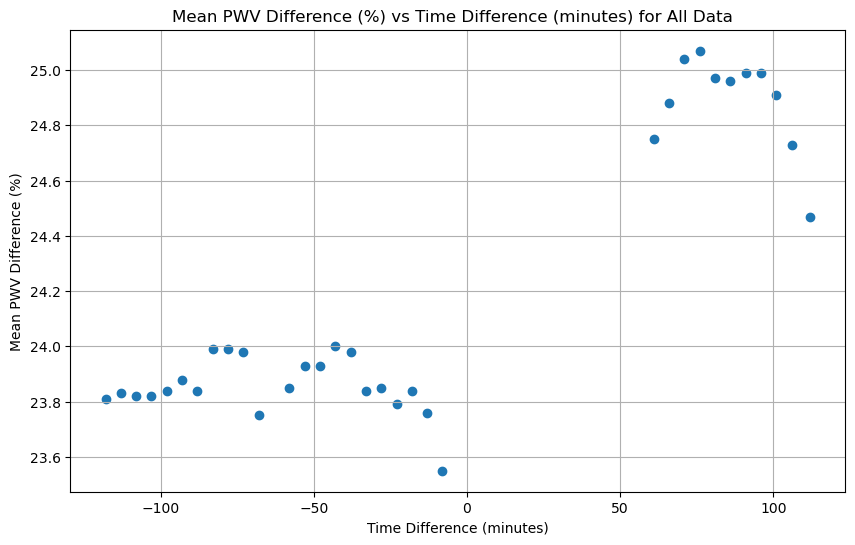

In [91]:
import pandas as pd 
import numpy as np  
import matplotlib.pyplot as plt
import glob
import os
from datetime import datetime, timedelta
import pickle
import matplotlib.pyplot as plt

# read txt file

Delta_Ts = []   
mean_PWV_diffs = []
counts = []
Std_devs = []

with open('total_around_stats.txt', 'r') as f:
    lines = f.readlines()
    for line in lines:
        parts = line.strip().split(',')
        delta_T = float(parts[0].split(':')[1].strip().split(' ')[0])
        count = int(parts[1].split(':')[1].strip())
        # if count < 200:
        #     continue
        mean_PWV_diff = float(parts[2].split(':')[1].strip())
        std_dev = float(parts[3].split(':')[1].strip())
        
        Delta_Ts.append(delta_T)
        counts.append(count)
        mean_PWV_diffs.append(mean_PWV_diff)
        Std_devs.append(std_dev)
#print(Delta_Ts)
new_total = pd.DataFrame({
    'Delta_T': Delta_Ts,
    'Mean_PWV_Diff': mean_PWV_diffs,
})
new_total = new_total.sort_values(by='Delta_T')
new_total.to_csv('Total_around_filtered.csv', index=False)

plt.figure(figsize=(10,6))
plt.errorbar(Delta_Ts, mean_PWV_diffs, yerr=Std_devs, fmt='o', ecolor='r', capthick=2, capsize=5)
plt.xlabel('Time Difference (minutes)')
plt.ylabel('Mean PWV Difference (%)')
plt.title('Mean PWV Difference (%) vs Time Difference (minutes) for All Data ')
plt.grid()
plt.savefig('All_Data_Errorbar.png')
plt.show()
plt.close()
plt.figure(figsize=(10,6))
plt.scatter(Delta_Ts, mean_PWV_diffs)
plt.xlabel('Time Difference (minutes)')
plt.ylabel('Mean PWV Difference (%)')
plt.title('Mean PWV Difference (%) vs Time Difference (minutes) for All Data  ')
plt.grid()
plt.savefig('All_Data_Scatter.png')
plt.show()
plt.close()
